# Семинар 2 - Цветовые пространства, гистограммы изображений, интегральные изображения

***

**Данный семинар содержит домашнее задание - оцениваемые упражнения и вопросы.**

Система оценивания: доля правильно решенных упражений. Максимальный балл, соответственно, 1.

В упражнениях оценивается два аспекта:
1. Код проходит assert'ы (если они есть)
2. Код корректен с точки зрения логики

Вопросы также оцениваются. Ответ на них нужно записывать в соответствующие markdown-ячейки.

Источник используемого аэрофотоснимка: https://sovzond.ru/upload/medialibrary/267/%D0%98%D1%81%D1%85%D0%BE%D0%B4%D0%BD%D1%8B%D0%B9-%D0%B0%D1%8D%D1%80%D0%BE%D1%84%D0%BE%D1%82%D0%BE%D1%81%D0%BD%D0%B8%D0%BC%D0%BE%D0%BA.jpg

In [1]:
from pathlib import Path

import cv2
import numpy as np

import matplotlib.pyplot as plt

In [15]:
AERIAL_IMG_PATH = "data/aerial_image.jpg"
SUNFLOWER_IMG_PATH = "data/sunflower.jpg"

if not Path(AERIAL_IMG_PATH).exists() or not Path(SUNFLOWER_IMG_PATH).exists():
    !git clone https://github.com/alexmelekhin/cv_course_2025.git
    !mv cv_course_2025/seminars/seminar_02/data .

Cloning into 'cv_course_2025'...
remote: Enumerating objects: 161, done.
remote: Counting objects: 100% (31/31), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 161 (delta 14), reused 12 (delta 12), pack-reused 130 (from 1)
Receiving objects: 100% (161/161), 53.04 MiB | 28.80 MiB/s, done.
Resolving deltas: 100% (28/28), done.


In [16]:
!ls data/

aerial_image.jpg  sunflower.jpg


# 1. Цветовые пространства

Наиболее распространенным представлением цвета пикселя является пространство RGB. В таком представлении цвет представлен тремя числами: интенсивностями красного, зеленого и синего базисных цветов.

In [17]:
img = cv2.imread(SUNFLOWER_IMG_PATH)

In [18]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

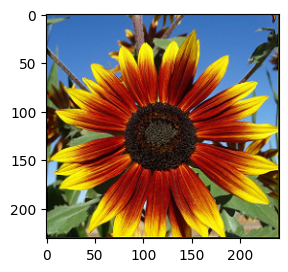

In [19]:
plt.figure(figsize=[3, 3])
plt.imshow(img_rgb);

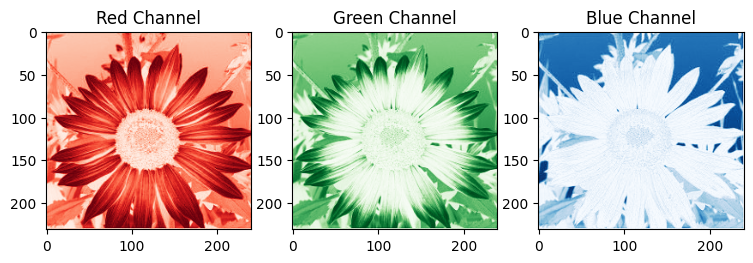

In [20]:
plt.figure(figsize=[9, 3])

plt.subplot(131)
plt.imshow(img_rgb[:,:,0], cmap='Reds')
plt.title('Red Channel')

plt.subplot(132)
plt.imshow(img_rgb[:,:,1], cmap='Greens')
plt.title('Green Channel')

plt.subplot(133)
plt.imshow(img_rgb[:,:,2], cmap='Blues')
plt.title('Blue Channel')

plt.show()

cvtColor поддерживает конвертацию между множеством других цветовых схем. К примеру, чтобы получить серое изобаржение из цветного достаточно:

In [21]:
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

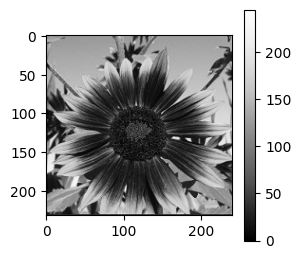

In [22]:
plt.figure(figsize=[3, 3])
plt.imshow(img_gray, cmap='Greys_r')
plt.colorbar()
plt.show()

## Вопрос 1

**Этот и все последующие вопросы - оцениваемые, для самостоятельной работы.**

Можно ли получить черно-белое изображение из RGB представления путем вычисления среднего значения интенсивностей каналов R, G и B? Почему?

**Ответ:** Формально это возможно (путем деления суммы каналов на 3), но такой метод некорректен с точки зрения особенностей человеческого зрения. Для получения реалистичного черно-белого изображения используется взвешенное среднее значение, учитывающее восприятие глаз. Чаще всего в стандартах компьютерного зрения используется формула Y = 0.299*R + 0.587*G + 0.114*B.

## Вопрос 2

Почему мы использовали флаг `cmap='Greys_r'` при отображении черно-белого изображения? Чем отличается от `cmap='Greys'`?

**Ответ:** `cmap='Greys_r'` где r по сути означает reversed, задает белый цвет более низким значениям и черный более высоким (простыми словами - меньшие значения светлее, большие темнее)

Если не предполагается использовать информацию о цвете пикселей, то можно сразу загрузить изображение в оттенках серого:

In [23]:
img_gray = cv2.imread(SUNFLOWER_IMG_PATH, cv2.IMREAD_GRAYSCALE)

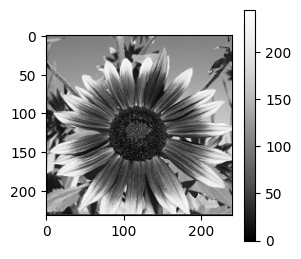

In [24]:
plt.figure(figsize=[3, 3])
plt.imshow(img_gray, cmap='Greys_r')
plt.colorbar()
plt.show()

серое изображение - двумерный массив:

In [25]:
print('type(img_gray) = ', type(img_gray))
print('img_gray.shape = ', img_gray.shape)
print('img_gray.dtype = ', img_gray.dtype)

type(img_gray) =  <class 'numpy.ndarray'>
img_gray.shape =  (231, 240)
img_gray.dtype =  uint8


## Упражнение 1: RGB to gray

**Это и все последующие упражения - оцениваемые, для самостоятельной работы.**

Реализуйте функцию преобразования цветного изображения в формате RGB в серое

In [26]:
def convert_rgb_to_grayscale(img_rgb):
    img = img_rgb.astype(np.float32)
    img_gray = 0.299 * img[:, :, 0] + 0.587 * img[:, :, 1] + 0.114 * img[:, :, 2]
    img_gray = np.clip(np.round(img_gray), 0, 255).astype(np.uint8)
    
    return img_gray

In [28]:
assert(np.abs((cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY) - convert_rgb_to_grayscale(img_rgb))).max() <= 1)

Кроме RGB/BGR и grayscale существуют и другие цветовые представления. Преобразования между ними можно осуществлять с помощью библиотеки OpenCV следующим способом:

## RGB to HSV

HSV - цветовое пространство, в котором цвет представлен тремя компонентами: Hue (оттенок), Saturation (насыщенность) и Value (значение). Это позволяет задавать цвета в более естественной форме, чем RGB.

In [29]:
img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

можно попробовать отобразить изображение так же, как и RGB:

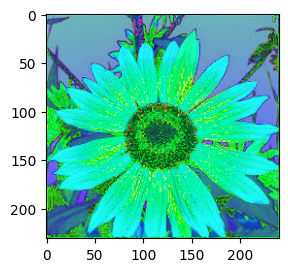

In [30]:
plt.figure(figsize=[3, 3])
plt.imshow(img_hsv);

Однако это не совсем корректно, так как Hue - это угол, а не интенсивность. Поэтому лучше отобразить оттенок в виде цвета, а насыщенность и значение - в виде яркости:

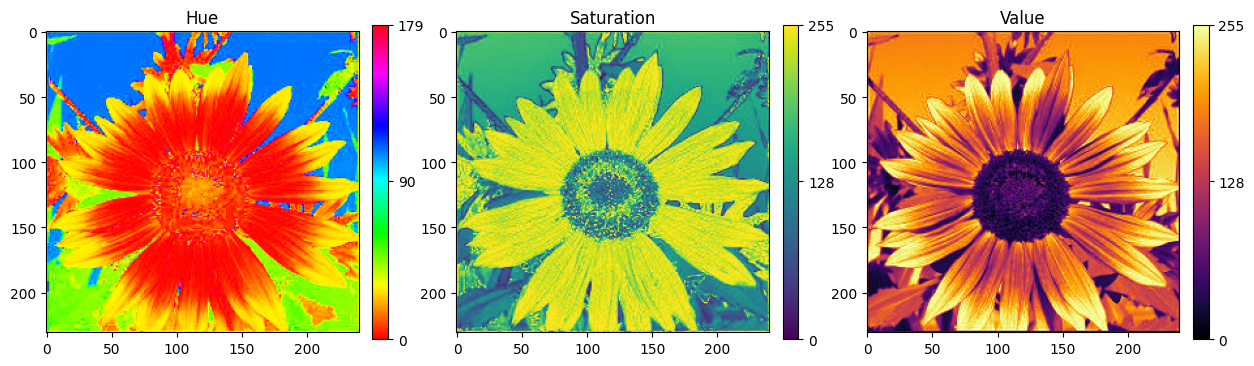

In [31]:
h, s, v = cv2.split(img_hsv)

fig, axs = plt.subplots(1, 3, figsize=[15, 5])

im1 = axs[0].imshow(h, cmap="hsv")
axs[0].set_title('Hue')
cbar1 = plt.colorbar(im1, ax=axs[0], fraction=0.046, pad=0.04, ticks=[0, 90, 179])
cbar1.ax.set_yticklabels(['0', '90', '179'])

im2 = axs[1].imshow(s, cmap="viridis")  # Using 'viridis' for Saturation
axs[1].set_title('Saturation')
cbar2 = plt.colorbar(im2, ax=axs[1], fraction=0.046, pad=0.04, ticks=[0, 128, 255])
cbar2.ax.set_yticklabels(['0', '128', '255'])

im3 = axs[2].imshow(v, cmap="inferno")  # Using 'inferno' for Value
axs[2].set_title('Value')
cbar3 = plt.colorbar(im3, ax=axs[2], fraction=0.046, pad=0.04, ticks=[0, 128, 255])
cbar3.ax.set_yticklabels(['0', '128', '255'])

plt.show()

## Упражнение 2

Попробуйте другие цветовые пространства, конвертация в которые реализована в OpenCV.

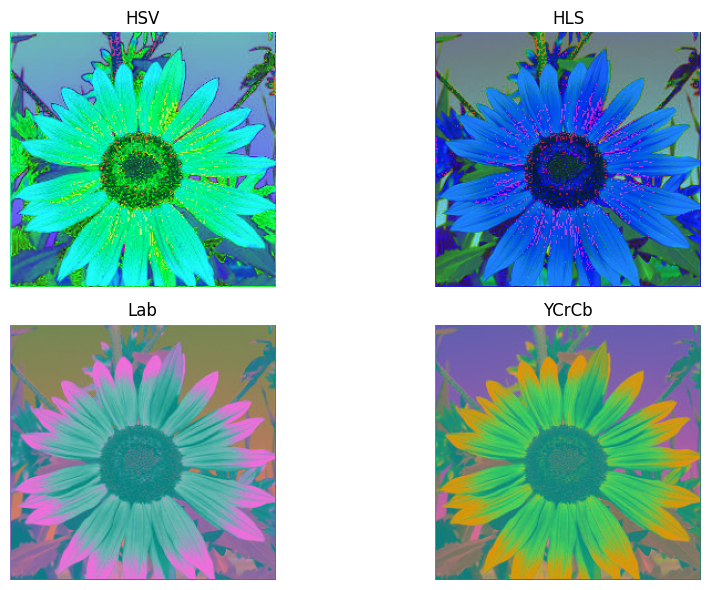

In [32]:
img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV) # повторим для наглядности
img_hls = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HLS)
img_lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2Lab)
img_ycrcb = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2YCrCb)

spaces = [('HSV', img_hsv), ('HLS', img_hls), ('Lab', img_lab), ('YCrCb', img_ycrcb)]
plt.figure(figsize=(10, 6))
for i, (name, img_space) in enumerate(spaces):
    plt.subplot(2, 2, i + 1)
    plt.imshow(img_space)
    plt.title(f'{name}')
    plt.axis('off')
plt.tight_layout()
plt.show()

## Вопрос 3

В каких задачах переход из RGB в другое цветовое пространство может быть полезным?

**Ответ:** Переход в пространства типа HSV или Lab полезен в задачах цветовой сегментации и трекинга объектов, так как позволяет отделить собственный цвет объекта от его освещенности.

# 2. Гистограмма изображения

Напомним, что гистограммой изображения называется функция, показыващая количество пикселей изображения с заданным в качестве аргумента значением интенсивности:

$$
    h(v) = \sum_{x = 0}^{W - 1} \sum_{y = 0}^{H - 1} [f(x, y) = v] 
$$

Если дополнительно потребовать, чтобы $\sum_{v = 0}^{255} h(v) = 1$, то $h$ будет представлять функцию плотности распределения интенсивности на изображении.

Определим вспомогательную функцию, позволяющую визуализировать гистограмму:

In [33]:
def visualize_hist(hist):
    plt.figure(figsize=[12, 3])
    plt.bar(np.arange(len(hist)), hist / hist.sum())

Рассчитать гистограмму можно с помощью встроенной функции OpenCV:

In [34]:
hist_cv = cv2.calcHist([img_gray],      # список изображений
                       [0],             # список каналов
                       None,            # маска (без маски)
                       [256],           # размер гистограммы
                       [0, 256])[:, 0]  # диапазон значений

Результат представляет собой обычный массив длины 256:

In [35]:
print('hist_cv.shape = ', hist_cv.shape)

hist_cv.shape =  (256,)


и выглядит следующим образом:

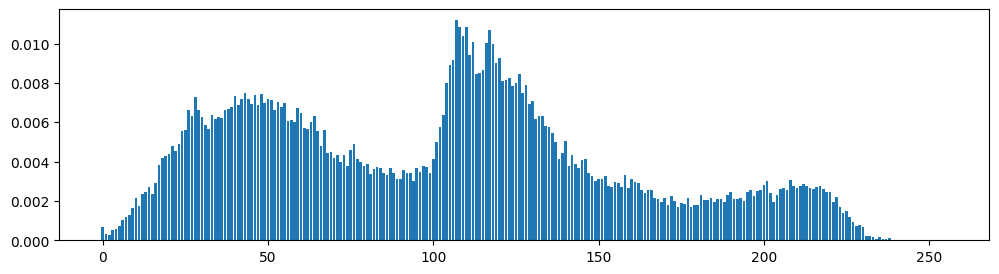

In [36]:
visualize_hist(hist_cv)

## Упражнение 3: Построение гистограммы

Реализуйте функцию для расчета гистограммы изображения. Используйте ее для визуализации трех каналов RGB изображения.

In [37]:
def compute_hist(img):
    histogramm = np.bincount(img.reshape(-1), minlength=256).astype(np.float32)
    return histogramm

In [38]:
hist_gray = compute_hist(img_gray)

hist_r = compute_hist(img_rgb[:, :, 0])
hist_g = compute_hist(img_rgb[:, :, 1])
hist_b = compute_hist(img_rgb[:, :, 2])

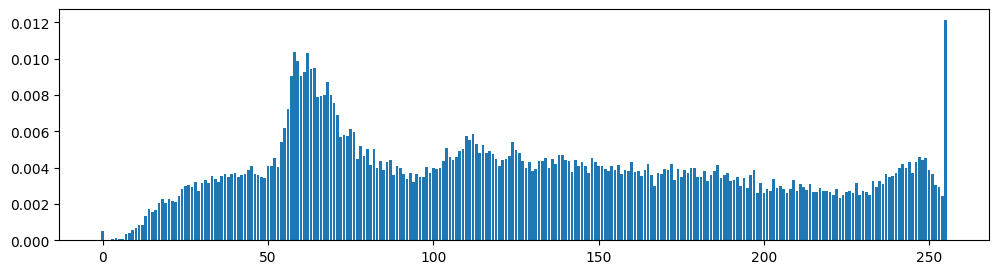

In [39]:
visualize_hist(hist_r)

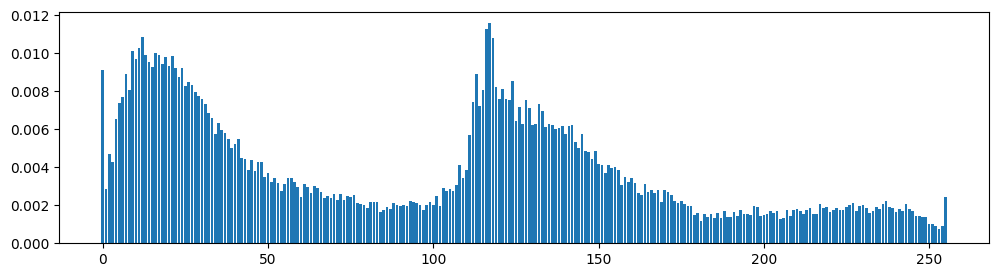

In [40]:
visualize_hist(hist_g)

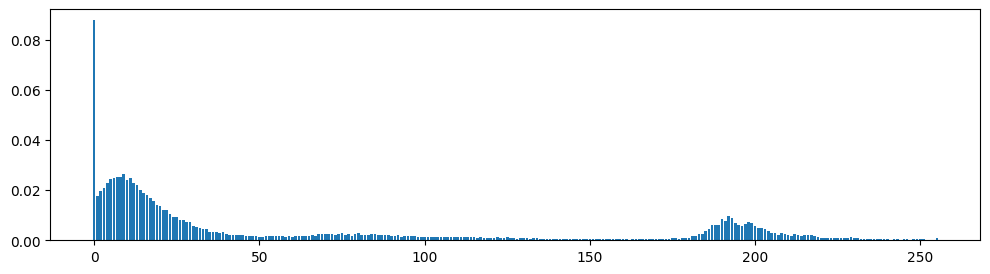

In [41]:
visualize_hist(hist_b)

In [42]:
assert((hist_gray == hist_cv).all())

## Вопрос 4

 Что можно сказать об изображении по его гистограмме?

**Ответ:** Гистограмма показывает распределение яркости и контрастности, позволяя судить об экспозиции (пересвет/недосвет) и динамическом диапазоне, но не дает информации о пространственном расположении объектов.

## Вопрос 5

Допустим, вы смотрите некоторый фильм и для текущего кадра выводите его гистограмму. Как будет меняться эта гистограмма с течением времени? Опишите несколько случаев: смена камеры, смена освещения, смена сцены.

**Ответ:** При движении камеры гистограмма меняется плавно, при изменении освещения она смещается влево (темнее) или вправо (светлее), а при смене сцены происходит резкое и кардинальное изменение её формы.

## Упражнение 4: JPEG и гистограмма

Исследуйте, как влияет степень сжатия алгоритма JPEG на вид гистограммы изображения.

Используйте черно-белое изображение `img_gray`. Визуализируйте степени сжатия 90, 60, 30, 5.

/tmp/ipython-input-2192102025.py:15: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(decoded_img.ravel(), 256, [0, 256], color='black', alpha=0.7)


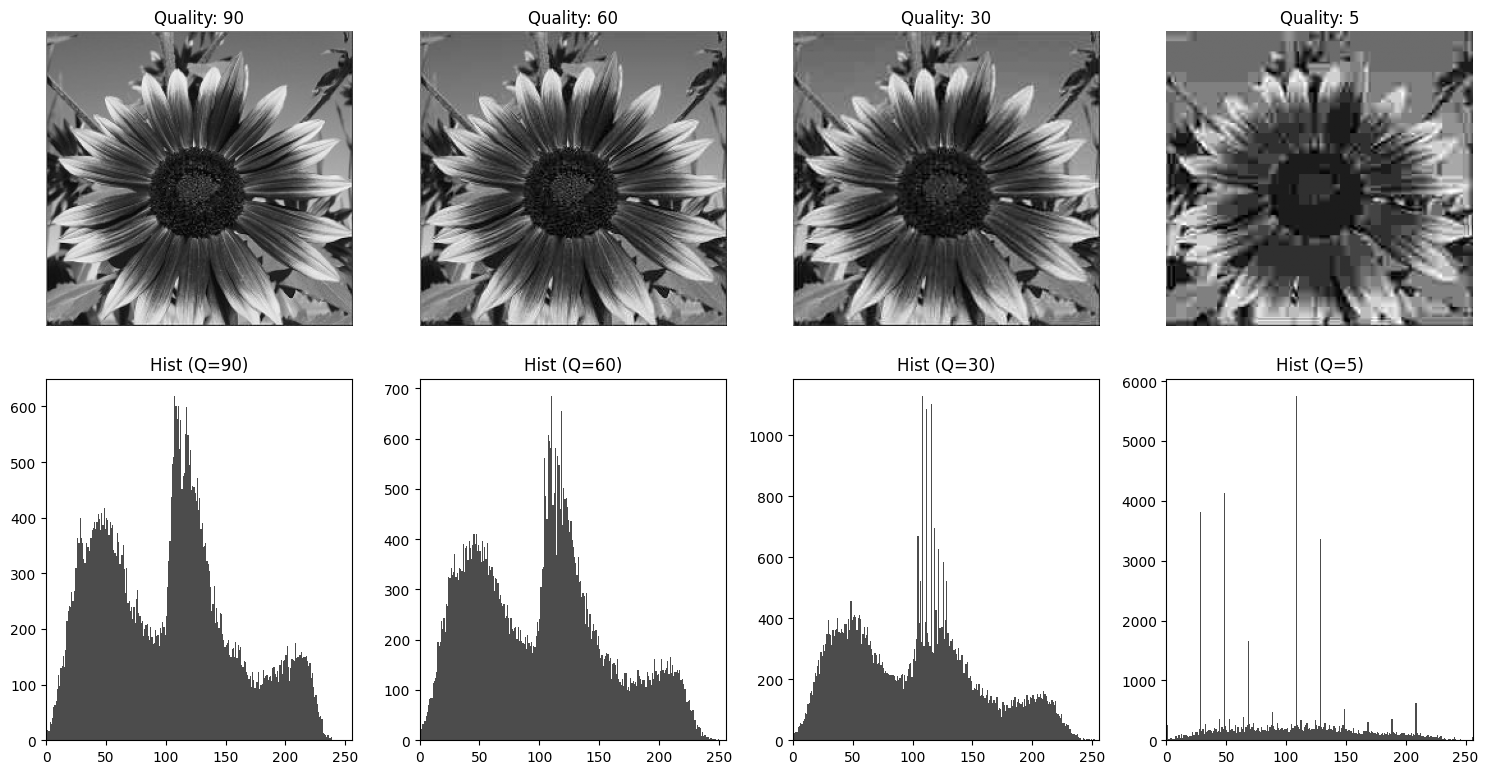

In [43]:
qualities = [90, 60, 30, 5]

plt.figure(figsize=(15, 8))

for i, quality in enumerate(qualities):
    _, encoded_img = cv2.imencode('.jpg', img_gray, [int(cv2.IMWRITE_JPEG_QUALITY), quality])
    decoded_img = cv2.imdecode(encoded_img, cv2.IMREAD_GRAYSCALE)
    
    plt.subplot(2, 4, i + 1)
    plt.imshow(decoded_img, cmap='gray')
    plt.title(f'Quality: {quality}')
    plt.axis('off')
    
    plt.subplot(2, 4, i + 5)
    plt.hist(decoded_img.ravel(), 256, [0, 256], color='black', alpha=0.7)
    plt.title(f'Hist (Q={quality})')
    plt.xlim([0, 256])

plt.tight_layout()
plt.show()

## Упражнение 5: Сегментация

На загруженном аэроортофотоплане выделите зеленые насаждения. Для этого постройте бинарную маску, где 1 будет отвечать наличию насаждений в данном пикселе, 0 - их отсутствию, и визуализируйте её. А также рассчитайте, какую долю изображения занимают зеленые насаждения. С какой ошибкой (погрешностью) получена эта величина?

**Подсказка:** вам должно помочь HSV пространство и гистограмма. Погрешность может быть оценена на глаз, по вашей неуверенности в определении порога отделения классов 'зеленые насаждения'/'прочее'.

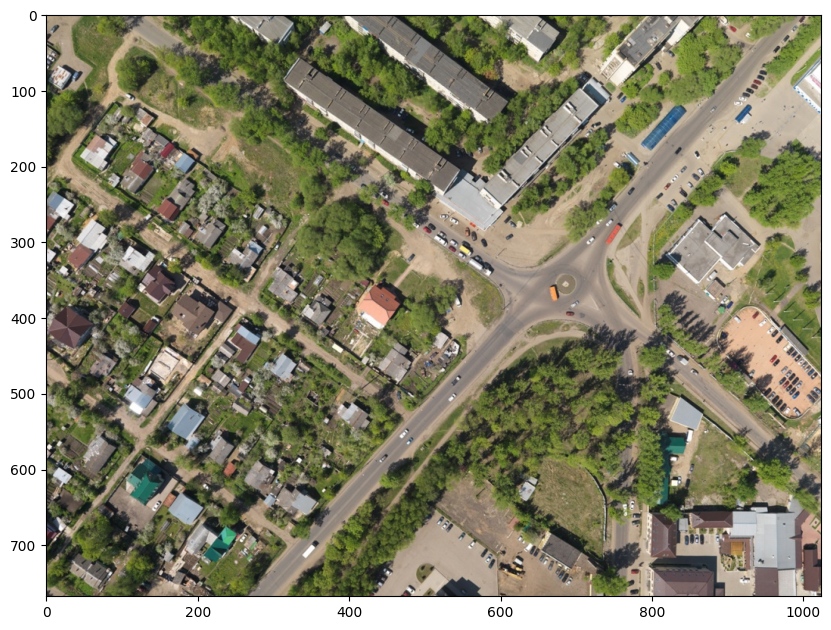

In [44]:
aerial_image = cv2.cvtColor(cv2.imread(AERIAL_IMG_PATH), cv2.COLOR_BGR2RGB)

plt.figure(figsize=[10, 10])
plt.imshow(aerial_image);

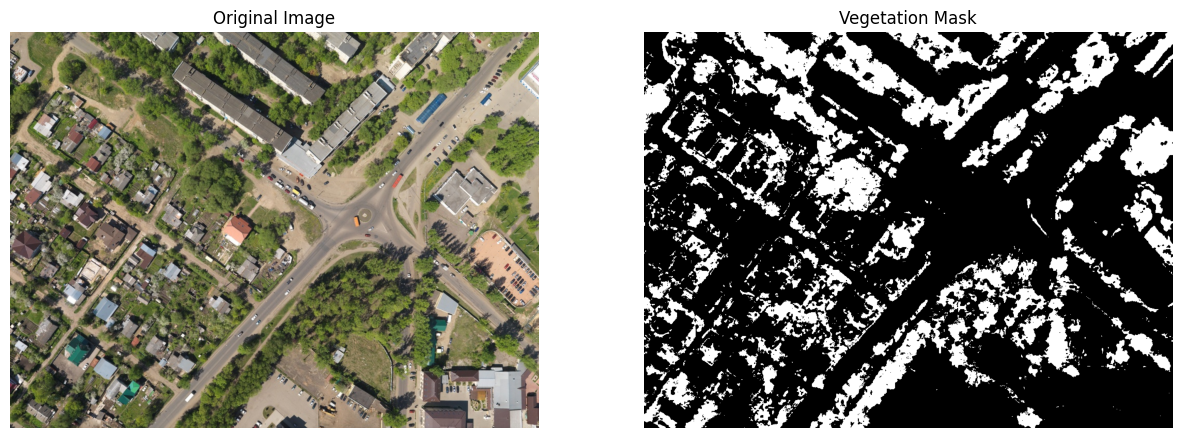

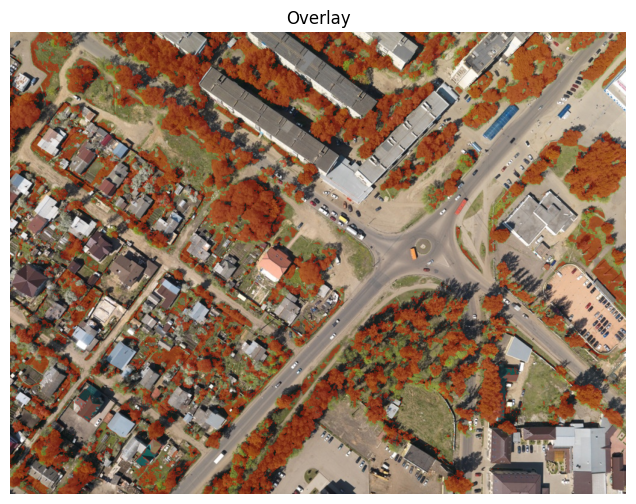

Доля зеленых насаждений: 0.2538 (или 25.38%)


In [45]:
hsv_img = cv2.cvtColor(aerial_image, cv2.COLOR_RGB2HSV)
hue = hsv_img[:, :, 0]

lower_green = np.array([35, 40, 40])
upper_green = np.array([85, 255, 255])

mask = cv2.inRange(hsv_img, lower_green, upper_green)
green_fraction = (mask > 0).mean()

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.imshow(aerial_image)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap='gray')
plt.title('Vegetation Mask')
plt.axis('off')

plt.show()

overlay = aerial_image.copy()
mask_color = np.array([255, 0, 0], dtype=np.uint8)
alpha = 0.35

beta = 1 - alpha
overlay[mask > 0] = (beta * overlay[mask > 0] + alpha * mask_color).astype(np.uint8)
plt.figure(figsize=(8, 6))
plt.imshow(overlay)
plt.title('Overlay')
plt.axis('off')
plt.show()

print(f"Доля зеленых насаждений: {green_fraction:.4f} (или {green_fraction*100:.2f}%)")

На глаз ошибка кажется в диапазоне от 10-15%. Есть ошибка семантическая, что дом с зеленой крышей тоже сегментируется.

# 3. Интегральные изображения

## Упражнение 6

Напомним, что интегральным изображением называется следующая функция:

$$
    I(x, y) = \sum_{i = 0}^{x} \sum_{j = 0}^{y} f(i, j)
$$

С помощью интегрального изображения можно за $O(1)$ вычислять сумму интенсивностей в произвольной прямоугольной области. Требуется реализовать расчет интегрального изображения, а также быстрый расчет сумм интенсивностей в прямоугольнике заданном верхним левым углом, шириной и высотой $x, y, w, h$.

In [46]:
class IntegralImage:

    def __init__(self, img):
        self.img = img
        img64 = img.astype(np.int64)
        self.integral = img64.cumsum(axis=0).cumsum(axis=1)

    def sum(self, x, y, w, h):
        x1, y1 = x, y
        x2, y2 = x + w - 1, y + h - 1

        final_sum = self.integral[y2, x2]
        if x1 > 0:
            final_sum -= self.integral[y2, x1 - 1]
        if y1 > 0:
            final_sum -= self.integral[y1 - 1, x2]
        if x1 > 0 and y1 > 0:
            final_sum += self.integral[y1 - 1, x1 - 1]
        
        final_sum = int(final_sum)

        return final_sum

In [47]:
I = IntegralImage(img_gray)

In [48]:
x, y, w, h = 0, 0, 100, 100
assert(img_gray[y:y + h, x:x + w].sum() == I.sum(x, y, w, h))

x, y, w, h = 100, 100, 100, 100
assert(img_gray[y:y + h, x:x + w].sum() == I.sum(x, y, w, h))

## Вопрос 6

В каких задачах может потребоваться использовать интегральное изображение?

**Ответ:** Интегральное изображение используется для вычисления суммы пикселей в произвольной прямоугольной области за константное время 
, что применяется в алгоритмах быстрого детектирования объектов и при расчетах локальных характеристик изображения.

## Вопрос 7

Какому методу решения задачи в программировании следует метод расчета интегрального изображения?

**Ответ:** Методу динамического программирования и структурному шаблону префиксных сумм (Prefix Sum / 2D Cumulative Sum). Вместо пересчета сумм прямоугольников заново каждый раз, происходит предвычисление суммы за один общий проход, а каждое последующее новое значение "запоминается" опираясь на выводы от предыдущих соседних элементов.